# PHT3D Example 5 — breakthrough curves at observation well S23

MF6PQC results are compared with the official PHT3D solution and the observations of Valocchi et al. (1981). The horizontal axis follows the official example and converts elapsed time to injected volume using $21\ \mathrm{m^3\,h^{-1}} \times 24\ \mathrm{h\,d^{-1}}$.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LogLocator, MultipleLocator, NullFormatter


# Support running either from this example directory or from the repository root.
CASE_DIR = Path.cwd()
if not (CASE_DIR / "output" / "results.npy").is_file():
    CASE_DIR = Path("examples") / "PHT3D_E05"
if not (CASE_DIR / "output" / "results.npy").is_file():
    raise FileNotFoundError("Run this notebook from the repository root or examples/PHT3D_E05.")

REFERENCE_FILE = CASE_DIR / "input_data" / "official_reference.npz"

results = np.load(CASE_DIR / "output" / "results.npy")
headings = (CASE_DIR / "output" / "results_headings.txt").read_text().splitlines()
component = {name.strip(): index for index, name in enumerate(headings)}

required = {"Ca", "Mg", "Na", "Cl"}
missing = required.difference(component)
if missing:
    raise ValueError(f"Missing components in results.npy: {sorted(missing)}")
if results.ndim != 3 or results.shape[2] != 17:
    raise ValueError(f"Expected (time, component, 17 cells), got {results.shape}")

SIMULATION_DAYS = 83.33
INJECTION_RATE_M3_PER_DAY = 21.0 * 24.0
OBSERVATION_CELL = -1

mf6pqc_time = np.linspace(0.0, SIMULATION_DAYS, results.shape[0])
mf6pqc_volume = mf6pqc_time * INJECTION_RATE_M3_PER_DAY


In [2]:
# Official PHT3D output at the last of the 17 model cells.
reference = np.load(REFERENCE_FILE)
pht3d_time = reference["time_days"]
pht3d_volume = pht3d_time * INJECTION_RATE_M3_PER_DAY
pht3d = {
    name: reference[name] for name in ("Ca", "Cl", "Na", "Mg")
}

# Observation data digitized in the official PHT3D Example 5 plotting script.
observed_volume = np.array([
    1, 123.012345, 205.021755, 256.276825, 266.528075, 297.281235,
    307.532485, 338.285645, 374.16443, 384.41568, 399.79226,
    502.303285, 584.31181, 630.441845, 666.32063, 768.83136,
    820.087315, 943.10025, 1127.620095, 1230.130825, 1332.642145,
    1435.152875, 1845.19668, 2255.24078, 2665.28281, 3382.8594,
    3792.90055, 4305.45715, 4818.0108, 5638.09605, 6355.6747,
    6868.22835, 7175.7629, 7585.80405, 8200.87315, 8815.93635,
    9841.0466, 10968.6664, 11686.248, 12403.82075, 13326.42145,
    15376.639, 17939.4161, 19477.07705, 21014.74095, 22552.4078,
    24602.6283, 28703.0516, 33828.594,
])

observed = {
    "Cl": np.array([
        np.nan, 0.160776, 0.134979, 0.110699, 0.087936, 0.089454,
        0.080349, 0.072761, 0.053034, 0.048481, 0.046964, 0.027236,
        0.022684, 0.019649, 0.016614, 0.013579, 0.015096, 0.010544,
        0.009026, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    ]),
    "Ca": np.array([
        np.nan, 0.01, np.nan, np.nan, np.nan, 0.00425, np.nan, np.nan,
        np.nan, np.nan, np.nan, 0.00115, np.nan, np.nan, 0.000775,
        np.nan, 0.000375, np.nan, 0.000325, 0.000312, 0.000275, np.nan,
        0.000275, 0.000275, 0.000275, 0.00025, np.nan, 0.000262, 0.0003,
        0.000375, 0.000475, np.nan, 0.000575, np.nan, 0.0007, 0.000775,
        0.00085, 0.00105, 0.001, 0.0008, 0.001025, 0.001125, 0.0012,
        0.00125, 0.001175, 0.001275, 0.0013, 0.00145, 0.001375,
    ]),
    "Mg": np.array([
        np.nan, 0.01646, np.nan, np.nan, np.nan, 0.006995, np.nan,
        np.nan, np.nan, np.nan, np.nan, 0.001893, np.nan, np.nan,
        0.001275, np.nan, 0.000658, np.nan, 0.000576, 0.000534,
        0.000493, 0.000452, 0.000493, 0.000493, 0.000493, 0.000452,
        0.000411, 0.000493, 0.000534, 0.000658, 0.000823, 0.000987,
        0.000987, 0.001234, 0.001234, 0.001481, 0.001522, 0.001646,
        0.001646, 0.001522, 0.001646, 0.001522, 0.001522, 0.001193,
        0.001152, 0.001069, 0.001028, 0.000987, 0.000864,
    ]),
}


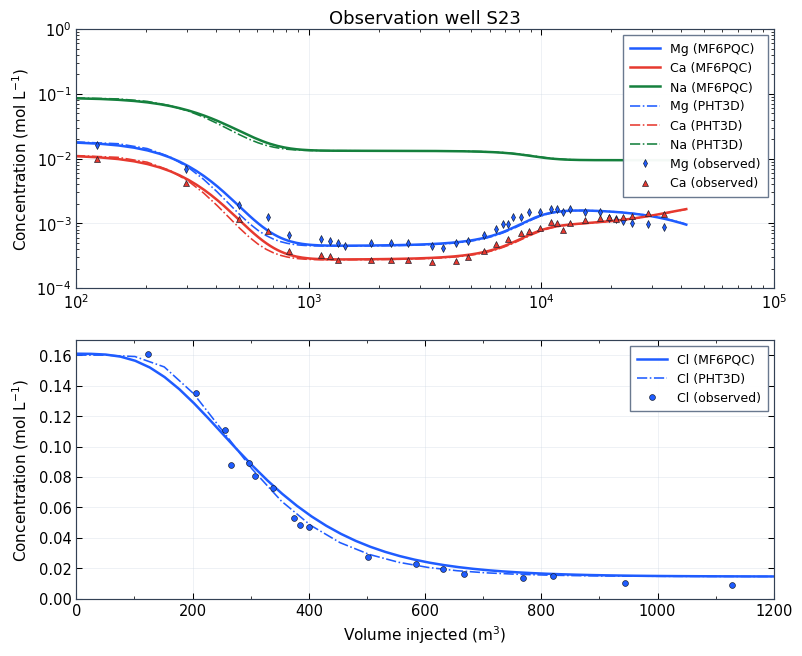

In [3]:
colors = {"Mg": "#1f5cff", "Ca": "#e6392f", "Na": "#15803d", "Cl": "#1f5cff"}
markers = {"Mg": "d", "Ca": "^", "Cl": "o"}

style = {
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.linewidth": 0.85,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 9,
}

with plt.rc_context(style):
    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, figsize=(9.0, 7.4), gridspec_kw={"hspace": 0.20}
    )

    # Cation breakthrough curves (log-log panel).
    positive_volume = mf6pqc_volume > 0
    for species in ("Mg", "Ca", "Na"):
        ax_top.plot(
            mf6pqc_volume[positive_volume],
            results[positive_volume, component[species], OBSERVATION_CELL],
            color=colors[species], lw=1.8, label=f"{species} (MF6PQC)",
        )
    for species in ("Mg", "Ca", "Na"):
        ax_top.plot(
            pht3d_volume[1:], pht3d[species][1:], color=colors[species],
            lw=1.15, ls="-.", label=f"{species} (PHT3D)",
        )
    for species in ("Mg", "Ca"):
        ax_top.plot(
            observed_volume, observed[species], ls="none", marker=markers[species],
            ms=4.2, mfc=colors[species], mec="#111827", mew=0.45,
            label=f"{species} (observed)", zorder=4,
        )

    ax_top.set(xscale="log", yscale="log", xlim=(1e2, 1e5), ylim=(1e-4, 1.0))
    ax_top.set_title("Observation well S23", pad=4)
    ax_top.set_ylabel(r"Concentration (mol L$^{-1}$)")
    ax_top.xaxis.set_major_locator(LogLocator(base=10))
    ax_top.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax_top.xaxis.set_minor_formatter(NullFormatter())
    ax_top.yaxis.set_major_locator(LogLocator(base=10))
    ax_top.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))
    ax_top.yaxis.set_minor_formatter(NullFormatter())
    ax_top.legend(
        loc="upper right", ncol=1, frameon=True, fancybox=False,
        framealpha=0.96, edgecolor="#64748b", columnspacing=1.1,
        handlelength=2.4, borderpad=0.55,
    )

    # Conservative chloride tracer (linear panel).
    ax_bottom.plot(
        mf6pqc_volume, results[:, component["Cl"], OBSERVATION_CELL],
        color=colors["Cl"], lw=1.8, label="Cl (MF6PQC)",
    )
    ax_bottom.plot(
        pht3d_volume, pht3d["Cl"], color=colors["Cl"], lw=1.15,
        ls="-.", label="Cl (PHT3D)",
    )
    ax_bottom.plot(
        observed_volume, observed["Cl"], ls="none", marker=markers["Cl"],
        ms=4.2, mfc=colors["Cl"], mec="#111827", mew=0.45,
        label="Cl (observed)", zorder=4,
    )

    ax_bottom.set(xlim=(0, 1200), ylim=(0, 0.17))
    ax_bottom.set_xlabel(r"Volume injected (m$^3$)")
    ax_bottom.set_ylabel(r"Concentration (mol L$^{-1}$)")
    ax_bottom.xaxis.set_major_locator(MultipleLocator(200))
    ax_bottom.xaxis.set_minor_locator(MultipleLocator(100))
    ax_bottom.yaxis.set_major_locator(MultipleLocator(0.02))
    ax_bottom.legend(
        loc="upper right", frameon=True, fancybox=False, framealpha=0.96,
        edgecolor="#64748b", handlelength=2.4, borderpad=0.55,
    )

    for ax in (ax_top, ax_bottom):
        ax.grid(which="major", color="#cbd5e1", lw=0.55, alpha=0.42)
        ax.tick_params(which="major", length=4.0, width=0.75)
        ax.tick_params(which="minor", length=2.2, width=0.55)
        for spine in ax.spines.values():
            spine.set_color("#334155")

    fig.align_ylabels((ax_top, ax_bottom))
    plt.show()